# Software Project Planning
## Intelligent Decision-Support System for SDLC

This notebook implements a decision-support framework for software project managers by combining:
- Critical Path Method (CPM)
- Monte Carlo risk simulation
- Criticality & intervention indices
- Constraint-based mitigation optimization using Z3


In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
from z3 import *
import random


In [ ]:
# PM-facing inputs ranges (hardcoded for now)
    """
    Requirements finalization
    Architecture design
    API development
    Frontend implementation
    Integration
    QA testing
    Deployment
    Compliance / Security review 
    """


tasks = {
    "REQ":  {"mean": 5, "min": 3, "max": 8, "deps": []},
    "ARCH": {"mean": 4, "min": 3, "max": 6, "deps": ["REQ"]},
    "API":  {"mean": 8, "min": 5, "max": 14, "deps": ["ARCH"]},
    "FE":   {"mean": 7, "min": 4, "max": 12, "deps": ["ARCH"]},
    "INT":  {"mean": 5, "min": 3, "max": 9, "deps": ["API", "FE"]},
    "QA":   {"mean": 6, "min": 4, "max": 10, "deps": ["INT"]},
    "DEP":  {"mean": 2, "min": 1, "max": 3, "deps": ["QA"]}
}


In [3]:
#CMP Engine 

def compute_cpm(tasks, durations):
    """
    Compute CPM schedule given tasks and deterministic durations.
    
    Parameters:
    - tasks: dict with task dependencies
    - durations: dict {task: duration}
    
    Returns:
    - schedule: dict with ES, EF, LS, LF, Float
    - project_duration
    - critical_path (list)
    """

    # ---------- Forward Pass ----------
    ES = {}
    EF = {}

    def forward(task):
        if task in ES:
            return
        if not tasks[task]["deps"]:
            ES[task] = 0
        else:
            ES[task] = max(EF[dep] for dep in tasks[task]["deps"])
        EF[task] = ES[task] + durations[task]

    for task in tasks:
        forward(task)

    project_duration = max(EF.values())

    # ---------- Backward Pass ----------
    LS = {}
    LF = {}

    for task in tasks:
        LF[task] = project_duration

    def backward(task):
        successors = [
            t for t in tasks if task in tasks[t]["deps"]
        ]
        if successors:
            LF[task] = min(LS[s] for s in successors)
        LS[task] = LF[task] - durations[task]

    for task in reversed(list(tasks.keys())):
        backward(task)

    # ---------- Float & Critical Path ----------
    schedule = {}
    critical_path = []

    for task in tasks:
        float_time = LS[task] - ES[task]
        schedule[task] = {
            "ES": ES[task],
            "EF": EF[task],
            "LS": LS[task],
            "LF": LF[task],
            "Float": float_time
        }
        if abs(float_time) < 1e-6:
            critical_path.append(task)

    return schedule, project_duration, critical_path


In [4]:
# Deterministic durations using mean values. Running above scheduler
mean_durations = {t: tasks[t]["mean"] for t in tasks}

schedule, total_duration, critical_path = compute_cpm(tasks, mean_durations)

print("Baseline Project Duration:", total_duration)
print("Critical Path:", " → ".join(critical_path))

pd.DataFrame(schedule).T


Baseline Project Duration: 30
Critical Path: REQ → ARCH → API → INT → QA → DEP


,ES,EF,LS,LF,Float
REQ,0,5,0,5,0
ARCH,5,9,5,9,0
API,9,17,9,17,0
FE,9,16,10,17,1
INT,17,22,17,22,0
QA,22,28,22,28,0
DEP,28,30,28,30,0


In [7]:
#MONTE CARLO SIMULATION (Triangular, PM-Realistic)
"""
Simulates uncertainty in software tasks
Produces:

-Distribution of delivery dates
Task criticality frequency
"""
# Number of Monte Carlo runs
N_SIM = 500

# Store results
project_durations = []
critical_counts = {task: 0 for task in tasks}

def sample_triangular_duration(task):
    """
    Sample duration using triangular distribution.
    """
    return np.random.triangular(
        task["min"],
        task["mean"],
        task["max"]
    )

for _ in range(N_SIM):
    # Sample durations for this simulation
    sampled_durations = {
        task: sample_triangular_duration(tasks[task])
        for task in tasks
    }

    # Run CPM with sampled durations
    _, total_duration, critical_path = compute_cpm(tasks, sampled_durations)

    project_durations.append(total_duration)

    # Count critical occurrences
    for task in critical_path:
        critical_counts[task] += 1


In [8]:
#Running Above Sumulations
print(f"Simulations run: {N_SIM}")
print(f"Mean duration: {np.mean(project_durations):.2f}")
print(f"P50 duration: {np.percentile(project_durations, 50):.2f}")
print(f"P90 duration: {np.percentile(project_durations, 90):.2f}")


Simulations run: 500
Mean duration: 33.34
P50 duration: 33.30
P90 duration: 36.86


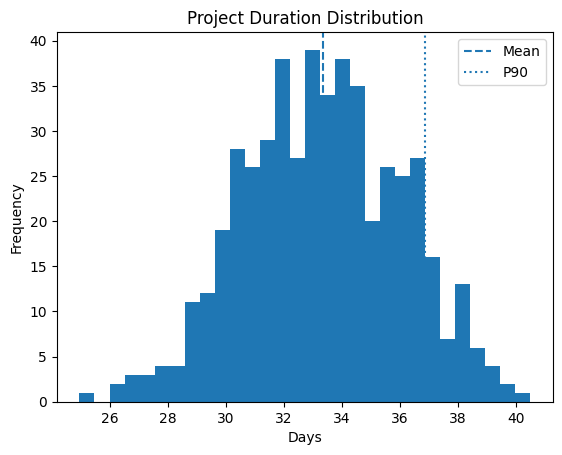

In [12]:
import matplotlib.pyplot as plt

plt.hist(project_durations, bins=30)
plt.axvline(np.mean(project_durations), linestyle="--", label="Mean")
plt.axvline(np.percentile(project_durations, 90), linestyle=":", label="P90")
plt.legend()
plt.title("Project Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()


<Axes: title={'center': 'Task Criticality Index'}>

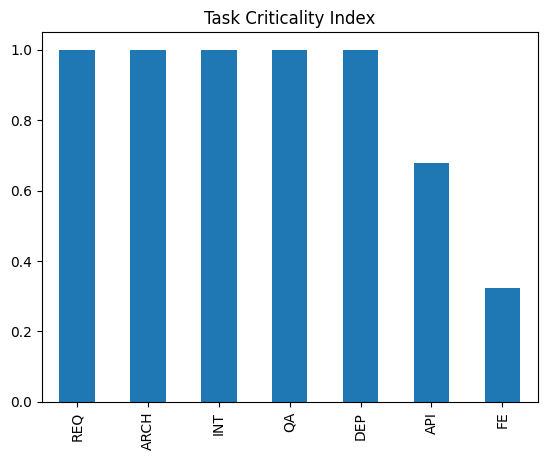

In [14]:
# Compute Criticality Index
criticality_index = {
    task: critical_counts[task] / N_SIM
    for task in tasks
}

# Convert to DataFrame for readability
criticality_df = pd.DataFrame.from_dict(
    criticality_index,
    orient="index",
    columns=["Criticality_Index"]
).sort_values(by="Criticality_Index", ascending=False)

criticality_df
criticality_df.plot(
    kind="bar",
    legend=False,
    title="Task Criticality Index"
)


In [15]:
#INTERVENTION INDEX (PM DECISION SIGNAL)
#Value creation for a PM “If I act here, will it actually reduce delivery risk?”

# PM-estimated rework / uncertainty amplification probabilities
rework_probability = {
    "REQ": 0.30,
    "ARCH": 0.20,
    "API": 0.45,
    "FE": 0.35,
    "INT": 0.50,
    "QA": 0.25,
    "DEP": 0.10
}

# Compute Intervention Index
intervention_index = {
    task: criticality_index[task] * rework_probability[task]
    for task in tasks
}

intervention_df = pd.DataFrame.from_dict(
    intervention_index,
    orient="index",
    columns=["Intervention_Index"]
).sort_values(by="Intervention_Index", ascending=False)

intervention_df


,Intervention_Index
INT,0.5000
API,0.3051
REQ,0.3000
QA,0.2500
ARCH,0.2000
FE,0.1127
DEP,0.1000


In [16]:
#Z3 OPTIMIZATION (PM-REALISTIC MITIGATION)

# Mitigation actions PMs actually understand
mitigations = {
    "REQ": {"risk_reduction": 0.20, "cost": 40},   # scope freeze
    "API": {"risk_reduction": 0.30, "cost": 80},   # add backend engineer
    "FE":  {"risk_reduction": 0.20, "cost": 60},   # UI library reuse
    "INT": {"risk_reduction": 0.35, "cost": 70},   # integration spike
    "QA":  {"risk_reduction": 0.15, "cost": 50}    # test automation
}

BUDGET = 120

# Z3 model
opt = Optimize()

decision_vars = {
    task: Int(task)
    for task in mitigations
}

# Binary constraints
for var in decision_vars.values():
    opt.add(Or(var == 0, var == 1))

# Budget constraint
opt.add(
    Sum([
        decision_vars[t] * mitigations[t]["cost"]
        for t in mitigations
    ]) <= BUDGET
)

# Objective: maximize risk reduction weighted by intervention index
objective = Sum([
    decision_vars[t] *
    mitigations[t]["risk_reduction"] *
    intervention_index[t]
    for t in mitigations
])

opt.maximize(objective)
opt.check()
model = opt.model()

selected_mitigations = {
    t: model[decision_vars[t]].as_long()
    for t in mitigations
    if model[decision_vars[t]].as_long() == 1
}

selected_mitigations


{'REQ': 1, 'INT': 1}

In [17]:
# POST-MITIGATION MONTE CARLO VALIDATION
def apply_mitigations(tasks, selected_mitigations):
    """
    Reduce uncertainty (max - mean spread) for mitigated tasks.
    """
    new_tasks = {}

    for task, params in tasks.items():
        params = params.copy()
        if task in selected_mitigations:
            reduction = mitigations[task]["risk_reduction"]
            params["max"] = params["mean"] + (params["max"] - params["mean"]) * (1 - reduction)
        new_tasks[task] = params

    return new_tasks


# Apply mitigations
mitigated_tasks = apply_mitigations(tasks, selected_mitigations)

# Re-run Monte Carlo
post_durations = []

for _ in range(N_SIM):
    sampled_durations = {
        task: sample_triangular_duration(mitigated_tasks[task])
        for task in mitigated_tasks
    }
    _, total_duration, _ = compute_cpm(mitigated_tasks, sampled_durations)
    post_durations.append(total_duration)

print("Before mitigation:")
print("P90:", np.percentile(project_durations, 90))

print("\nAfter mitigation:")
print("P90:", np.percentile(post_durations, 90))


Before mitigation:
P90: 36.860446739466965

After mitigation:
P90: 36.13549225259415
